#Visualizations and Insights

#This notebook uses the engineered dataset because it includes derived variables such as `Loss_Rate`, `Illegal_Logging_Flag`, `Population_Pressure`, and `Fire_Logging_Impact`.

```
Visual guide:
- Bar charts compare categories and ranks.
- The boxplot shows spread and outliers across risk groups.
- The line chart shows change over time.
```

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

BASE_DIR = Path.cwd()
if (BASE_DIR / 'data').exists():
    project_dir = BASE_DIR
else:
    project_dir = BASE_DIR.parent

data_path = project_dir / 'data' / 'engineered' / 'deforestation_features.csv'
output_dir = project_dir / 'visuals' / 'visualization_outputs'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
# Tolerate mixed or invalid date strings in the source data.
df['Observation_Date'] = pd.to_datetime(df['Observation_Date'], errors='coerce', dayfirst=True)
df.head()

,Record_ID,Observation_Date,Region,District,Forest_Type,Forest_Area_ha,Tree_Cover_Loss_ha,Annual_Rainfall_mm,Population_Density,Fire_Incidents,Illegal_Logging,Deforestation_Risk,Illegal_Logging_Flag,Population_Pressure,Fire_Logging_Impact
0,REC00001,2024-06-27,Central,Wakiso,Mangrove,4179.46,235.27,1358.1,657.0,16,Yes,High,1.0,0.157197,16.0
1,REC00002,2021-04-30,Eastern,Mbale,Mangrove,2072.03,14.36,1605.3,266.0,25,Yes,High,1.0,0.128377,25.0
2,REC00003,2022-01-20,Central,Mukono,Woodland,7417.11,543.23,1471.4,245.0,16,Yes,High,1.0,0.033032,16.0
3,REC00004,2021-07-17,Western,Mbarara,Montane Forest,5260.01,281.86,1609.9,434.0,11,Yes,High,1.0,0.082509,11.0
4,REC00005,2023-07-07,Eastern,Mbale,Dry Forest,9793.89,575.77,1353.5,647.0,6,No,High,0.0,0.066062,0.0


In [2]:
df.info()

df.describe(include='all').transpose()

<class 'pandas.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Record_ID             1397 non-null   str           
 1   Observation_Date      1396 non-null   datetime64[us]
 2   Region                1397 non-null   str           
 3   District              1397 non-null   str           
 4   Forest_Type           1397 non-null   str           
 5   Forest_Area_ha        1397 non-null   float64       
 6   Tree_Cover_Loss_ha    1397 non-null   float64       
 7   Annual_Rainfall_mm    1396 non-null   float64       
 8   Population_Density    1396 non-null   float64       
 9   Fire_Incidents        1397 non-null   int64         
 10  Illegal_Logging       1397 non-null   str           
 11  Deforestation_Risk    1397 non-null   str           
 12  Illegal_Logging_Flag  1396 non-null   float64       
 13  Population_Pressure   1396 no

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Record_ID,1397,1384,REC00107,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Observation_Date,1396,NaN,NaN,NaN,2023-01-08 16:45:43.839541,2021-01-01 00:00:00,2022-01-28 06:00:00,2023-01-07 00:00:00,2024-01-03 00:00:00,2024-12-31 00:00:00,NaN
Region,1397,4,Western,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,1397,6,Mbale,254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Forest_Type,1397,6,Woodland,256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Forest_Area_ha,1397.0,NaN,NaN,NaN,5045.275641,121.3,2523.22,4997.01,7657.4,9992.51,2887.051846
Tree_Cover_Loss_ha,1397.0,NaN,NaN,NaN,201.686908,-500.0,56.08,144.98,301.82,762.79,180.193835
Annual_Rainfall_mm,1396.0,NaN,NaN,NaN,1675.666691,700.1,1161.875,1609.95,2049.95,99999.0,2683.584288
Population_Density,1396.0,NaN,NaN,NaN,459.768625,30.0,237.75,456.0,675.25,899.0,250.707881
Fire_Incidents,1397.0,NaN,NaN,NaN,12.163923,0.0,5.0,12.0,19.0,25.0,7.661044


#Key Variables and Visual Keys

```
The most useful variables are:
- `Region` and `District` for geographic comparisons.
- `Forest_Type` for ecosystem differences.
- `Forest_Area_ha`, `Tree_Cover_Loss_ha`, and `Loss_Rate` for environmental intensity.
- `Annual_Rainfall_mm`, `Population_Density`, `Fire_Incidents`, and `Fire_Logging_Impact` for relationships and pressure patterns.
- `Deforestation_Risk` for category-based analysis.
```

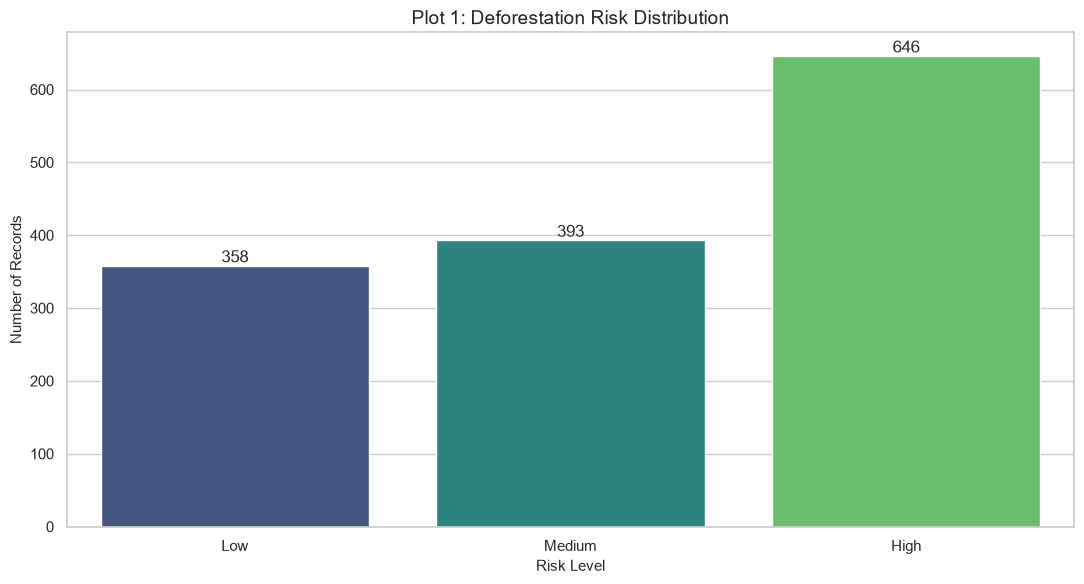

WindowsPath('c:/Users/Divine/Documents/GitHub/Deforestation-Tracking/visuals/visualization_outputs/01_risk_distribution.png')

In [3]:
# 1) Deforestation risk distribution
risk_counts = df['Deforestation_Risk'].value_counts().reindex(['Low', 'Medium', 'High'])
fig, ax = plt.subplots()
sns.barplot(x=risk_counts.index, y=risk_counts.values, ax=ax, palette='viridis')
ax.set_title('Plot 1: Deforestation Risk Distribution')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Records')
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
risk_path = output_dir / '01_risk_distribution.png'
fig.savefig(risk_path, dpi=300, bbox_inches='tight')
plt.show()
risk_path

**Interpretation:** If the `High` category dominates, the dataset suggests many observations are already under strong deforestation pressure. A balanced distribution would indicate risk is spread more evenly across locations.

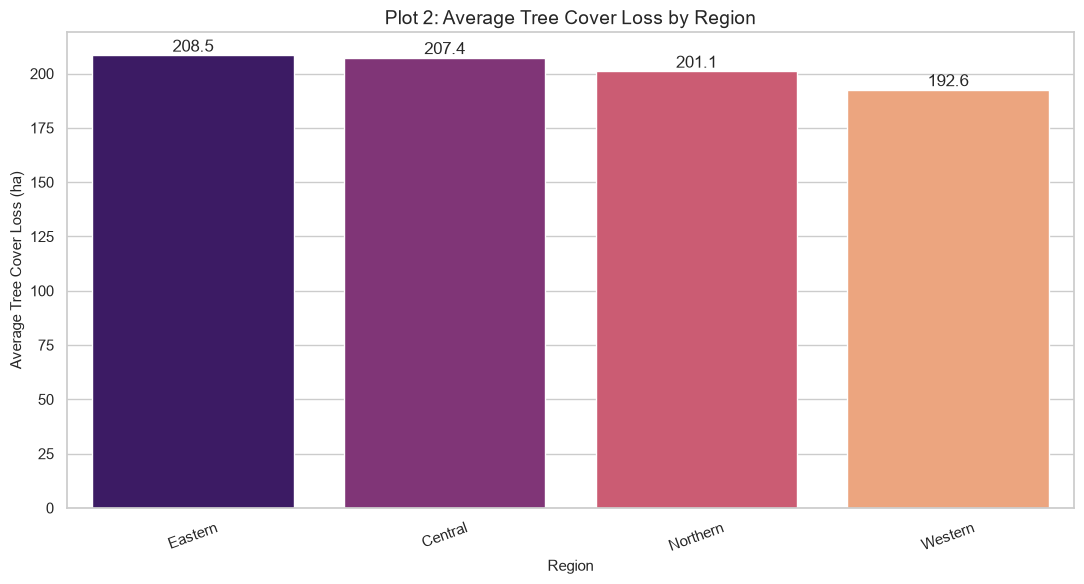

WindowsPath('c:/Users/Divine/Documents/GitHub/Deforestation-Tracking/visuals/visualization_outputs/02_tree_cover_loss_by_region.png')

In [4]:
# 2) Tree cover loss by region
region_loss = df.groupby('Region', as_index=False)['Tree_Cover_Loss_ha'].mean().sort_values('Tree_Cover_Loss_ha', ascending=False)
fig, ax = plt.subplots()
sns.barplot(data=region_loss, x='Region', y='Tree_Cover_Loss_ha', ax=ax, palette='magma')
ax.set_title('Plot 2: Average Tree Cover Loss by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Average Tree Cover Loss (ha)')
ax.tick_params(axis='x', rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
fig.tight_layout()
region_loss_path = output_dir / '02_tree_cover_loss_by_region.png'
fig.savefig(region_loss_path, dpi=300, bbox_inches='tight')
plt.show()
region_loss_path

**Interpretation:** Regions with higher average tree cover loss deserve priority attention because they are losing more forest area per observation. This makes the chart useful for regional comparison and intervention planning.

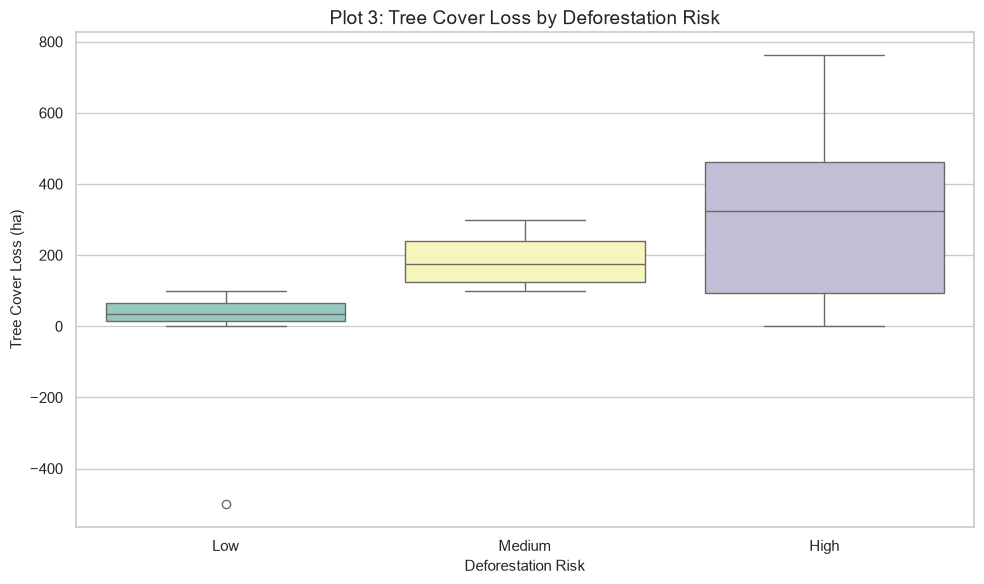

WindowsPath('c:/Users/Divine/Documents/GitHub/Deforestation-Tracking/visuals/visualization_outputs/03_tree_cover_loss_by_risk_boxplot.png')

In [5]:
# 3) Tree cover loss by deforestation risk
if 'Loss_Rate' not in df.columns and {'Tree_Cover_Loss_ha', 'Forest_Area_ha'}.issubset(df.columns):
    df['Loss_Rate'] = df['Tree_Cover_Loss_ha'] / df['Forest_Area_ha']

risk_order = ['Low', 'Medium', 'High']
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Deforestation_Risk', y='Tree_Cover_Loss_ha', order=risk_order, ax=ax, palette='Set3')
ax.set_title('Plot 3: Tree Cover Loss by Deforestation Risk')
ax.set_xlabel('Deforestation Risk')
ax.set_ylabel('Tree Cover Loss (ha)')
fig.tight_layout()
risk_loss_boxplot_path = output_dir / '03_tree_cover_loss_by_risk_boxplot.png'
fig.savefig(risk_loss_boxplot_path, dpi=300, bbox_inches='tight')
plt.show()
risk_loss_boxplot_path

**Interpretation:** The boxplot shows that regions with `High` deforestation risk have a wider spread of tree cover loss, indicating that some areas are experiencing extreme loss.

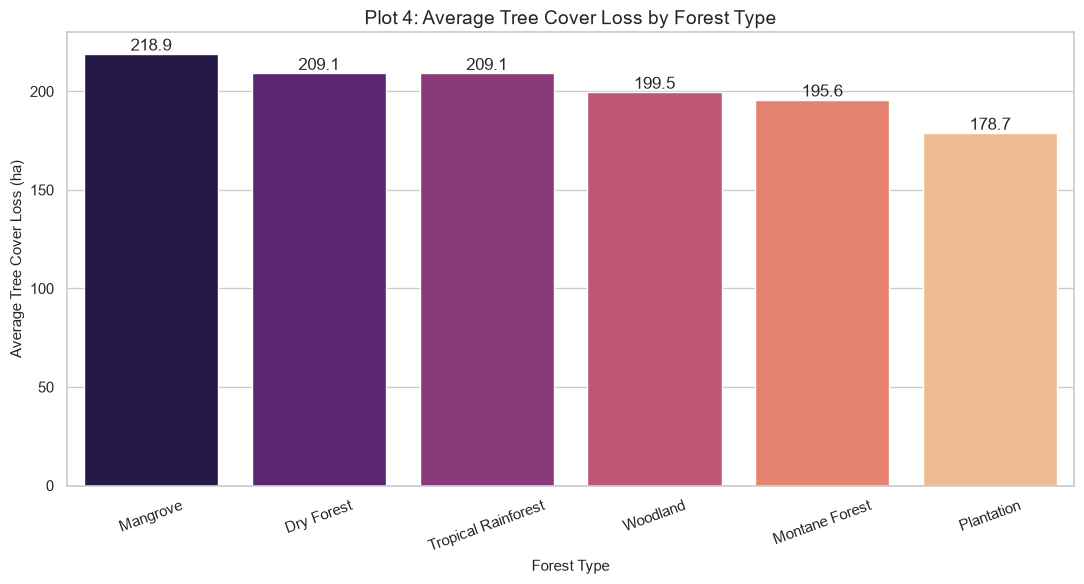

WindowsPath('c:/Users/Divine/Documents/GitHub/Deforestation-Tracking/visuals/visualization_outputs/04_tree_cover_loss_by_forest_type.png')

In [6]:
# 4) Average tree cover loss by forest type
forest_loss = df.groupby('Forest_Type', as_index=False)['Tree_Cover_Loss_ha'].mean().sort_values('Tree_Cover_Loss_ha', ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=forest_loss, x='Forest_Type', y='Tree_Cover_Loss_ha', ax=ax, palette='magma')
ax.set_title('Plot 4: Average Tree Cover Loss by Forest Type')
ax.set_xlabel('Forest Type')
ax.set_ylabel('Average Tree Cover Loss (ha)')
ax.tick_params(axis='x', rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
fig.tight_layout()
forest_loss_path = output_dir / '04_tree_cover_loss_by_forest_type.png'
fig.savefig(forest_loss_path, dpi=300, bbox_inches='tight')
plt.show()
forest_loss_path

**Interpretation:** The forest type chart shows which ecosystems are experiencing the highest average tree cover loss. Forest types with taller bars are more exposed to pressure and may need stronger protection.

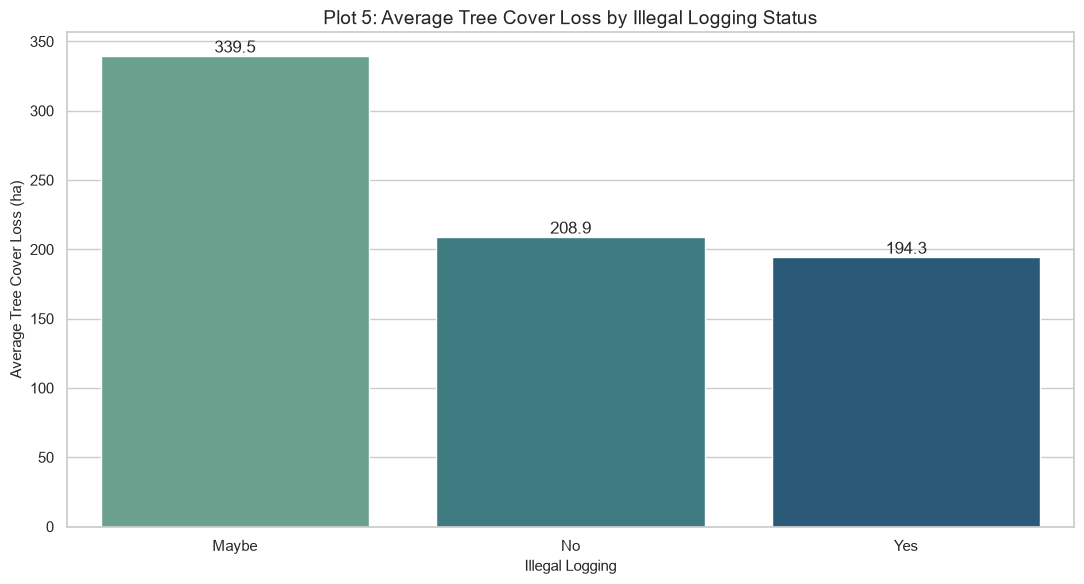

WindowsPath('c:/Users/Divine/Documents/GitHub/Deforestation-Tracking/visuals/visualization_outputs/05_tree_cover_loss_by_illegal_logging.png')

In [7]:
# 5) Average tree cover loss by illegal logging status
logging_loss = df.groupby('Illegal_Logging', as_index=False)['Tree_Cover_Loss_ha'].mean().sort_values('Tree_Cover_Loss_ha', ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=logging_loss, x='Illegal_Logging', y='Tree_Cover_Loss_ha', ax=ax, palette='crest')
ax.set_title('Plot 5: Average Tree Cover Loss by Illegal Logging Status')
ax.set_xlabel('Illegal Logging')
ax.set_ylabel('Average Tree Cover Loss (ha)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
fig.tight_layout()
logging_loss_path = output_dir / '05_tree_cover_loss_by_illegal_logging.png'
fig.savefig(logging_loss_path, dpi=300, bbox_inches='tight')
plt.show()
logging_loss_path

**Interpretation:** The illegal logging chart compares average tree cover loss for records with and without illegal logging. A higher bar for `Maybe` weakly supports the idea that illegal logging is linked to stronger forest loss.

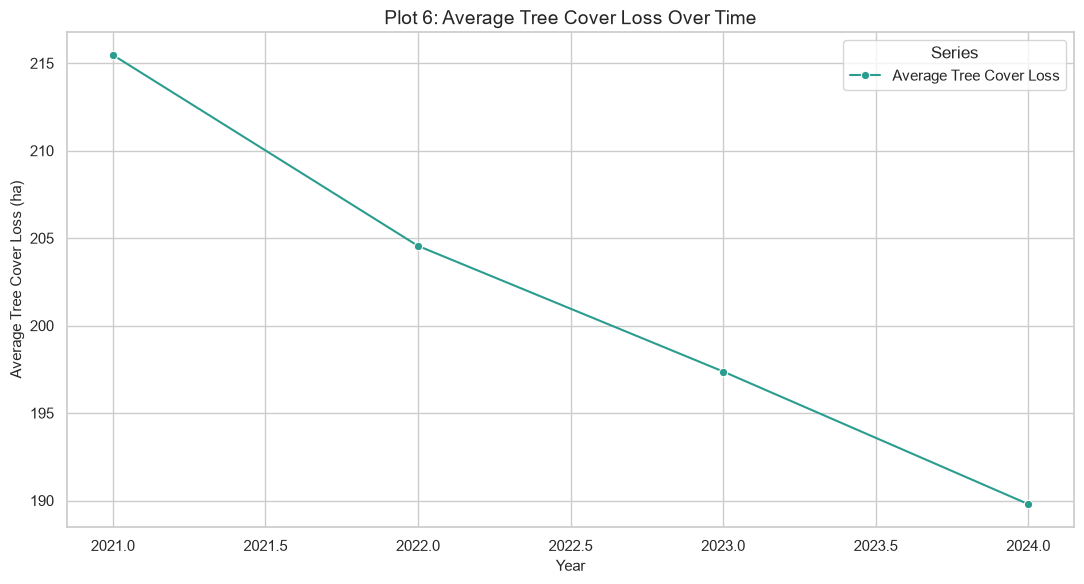

WindowsPath('c:/Users/Divine/Documents/GitHub/Deforestation-Tracking/visuals/visualization_outputs/06_average_tree_cover_loss_over_time.png')

In [8]:
# 6) Average tree cover loss over time
yearly_loss = df.dropna(subset=['Observation_Date']).copy()
yearly_loss['Year'] = yearly_loss['Observation_Date'].dt.year
yearly_loss = yearly_loss.groupby('Year', as_index=False)['Tree_Cover_Loss_ha'].mean().sort_values('Year')

fig, ax = plt.subplots()
sns.lineplot(data=yearly_loss, x='Year', y='Tree_Cover_Loss_ha', marker='o', ax=ax, color='#2a9d8f', label='Average Tree Cover Loss')
ax.set_title('Plot 6: Average Tree Cover Loss Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Average Tree Cover Loss (ha)')
ax.legend(title='Series', loc='best')
fig.tight_layout()
yearly_loss_path = output_dir / '06_average_tree_cover_loss_over_time.png'
fig.savefig(yearly_loss_path, dpi=300, bbox_inches='tight')
plt.show()
yearly_loss_path

**Interpretation:** The line chart shows how average tree cover loss changes over time. The line falls in later years, which suggests forest loss is becoming less severe over years.

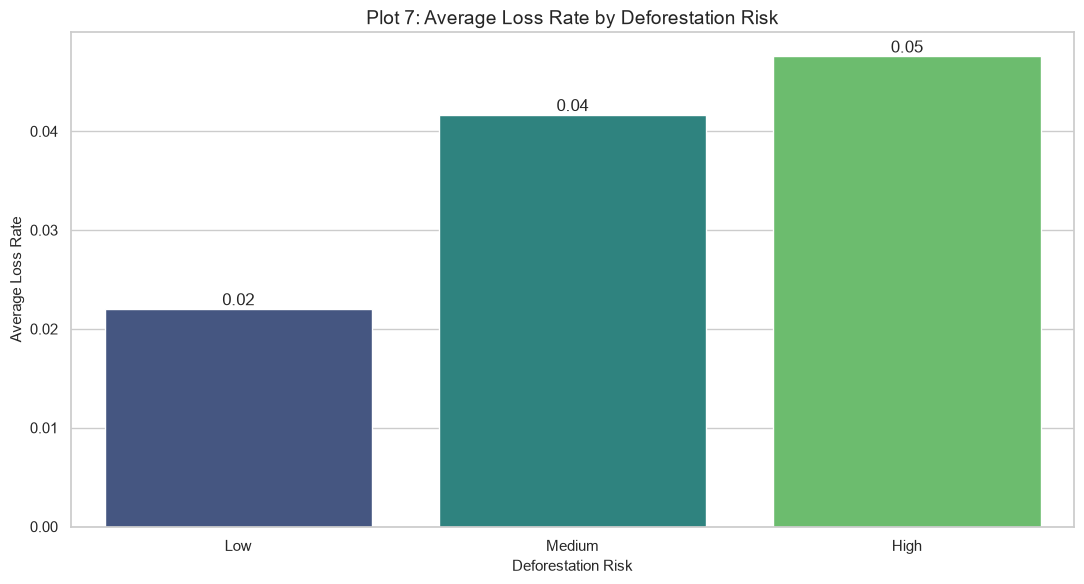

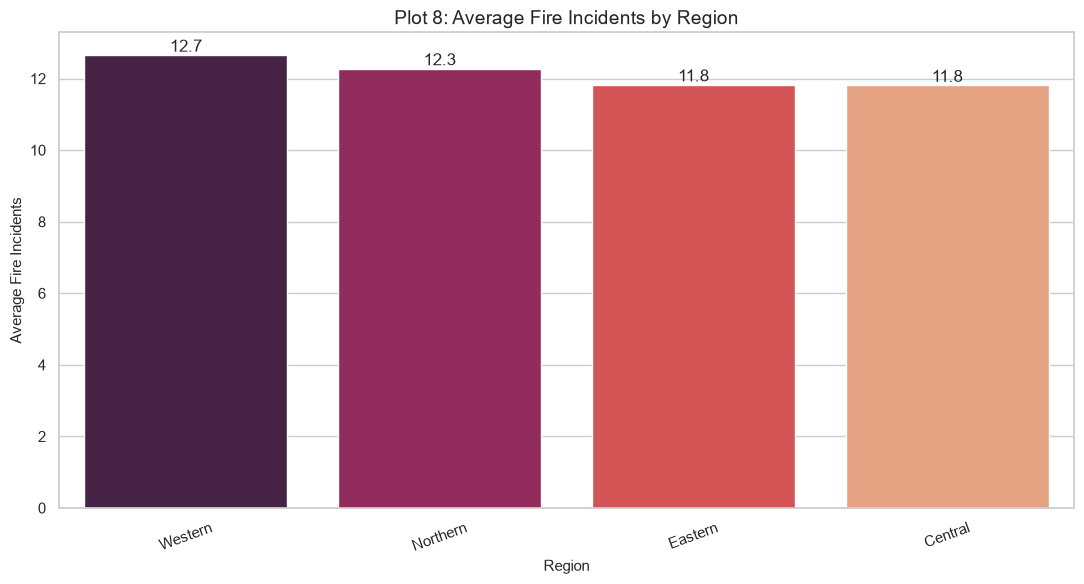

In [9]:
# 7) Average loss rate by deforestation risk
risk_loss_rate = (
    df.groupby('Deforestation_Risk', as_index=False)['Loss_Rate'].mean()
    .set_index('Deforestation_Risk')
    .reindex(['Low', 'Medium', 'High'])
    .reset_index()
 )

fig, ax = plt.subplots()
sns.barplot(data=risk_loss_rate, x='Deforestation_Risk', y='Loss_Rate', ax=ax, palette='viridis')
ax.set_title('Plot 7: Average Loss Rate by Deforestation Risk')
ax.set_xlabel('Deforestation Risk')
ax.set_ylabel('Average Loss Rate')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
fig.tight_layout()
risk_loss_rate_path = output_dir / '07_loss_rate_by_risk.png'
fig.savefig(risk_loss_rate_path, dpi=300, bbox_inches='tight')
plt.show()

# 8) Average fire incidents by region
fire_region = df.groupby('Region', as_index=False)['Fire_Incidents'].mean().sort_values('Fire_Incidents', ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=fire_region, x='Region', y='Fire_Incidents', ax=ax, palette='rocket')
ax.set_title('Plot 8: Average Fire Incidents by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Average Fire Incidents')
ax.tick_params(axis='x', rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
fig.tight_layout()
fire_region_path = output_dir / '08_fire_incidents_by_region.png'
fig.savefig(fire_region_path, dpi=300, bbox_inches='tight')
plt.show()

## Summary of Insights

Key observations:
- Plot 1 shows the overall risk distribution and tells us whether the dataset is dominated by low, medium, or high deforestation risk records.
- Plot 2 shows which regions have the highest average tree cover loss, helping identify the most affected locations.
- Plot 3 shows how tree cover loss is distributed across low, medium, and high risk groups.
- Plot 4 shows which forest types are experiencing the most loss on average.
- Plot 5 compares average tree cover loss for records with and without illegal logging.
- Plot 6 shows how average tree cover loss changes over time.
- Plot 7 shows how average loss rate changes with deforestation risk.
- Plot 8 shows which regions have the highest average fire incidents.

Deforestation is linked to location, forest type, illegal logging, fire activity, and changing trends over time.